# Data Analysis

In [2]:
#imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import fisher_exact

In [3]:
#load the files after they are clean
eugene = pd.read_csv("eugene.csv")
springfield = pd.read_csv("springfield.csv")

In [4]:
eugene["calltime"] = pd.to_datetime(eugene["calltime"], errors="coerce")
eugene.head(3)

,calltime,closed_as,agency,primeunit,is_cahoots,yr,month,month_date,city
0,2015-01-01 00:00:00,ASSISTED,EPD,_5E48,False,2015,1,2015-01-01,Eugene
1,2015-01-01 00:00:44,RESOLVED,EPD,_3F65,False,2015,1,2015-01-01,Eugene
2,2015-01-01 00:01:05,ASSISTED,CAHE,_3J79,True,2015,1,2015-01-01,Eugene


In [5]:
springfield["calltime"] = pd.to_datetime(springfield["calltime"], errors="coerce")
springfield.head(3)

,agency,prime unit,closed_as,calltime,yr,month,is_cahoots,month_date,city
0,SPD,1S12,ASSISTED,2015-01-01 00:01:00,2015.0,1.0,False,2015-01-01,Springfield
1,SPD,,DISREGARD,2015-01-01 00:04:00,2015.0,1.0,False,2015-01-01,Springfield
2,SPD,3S12,ARREST,2015-01-01 00:11:00,2015.0,1.0,False,2015-01-01,Springfield


## Step 1 Exploratory Analysis

Using pandas compute general frequencies of each variable in the closed_as column. Specifically focus on hospital transportations and arrests as well as splitting frequencies by agency and normalizing those counts. Finally, compare change over time of hospital and arrest outcomes.  It’s important to mark at least roughly where MCSLC started activities in Eugene and when CAHOOTS stopped services because these are our main points of interest in time to measure if there has been a difference between agencies. 

### *Eugene*

In [6]:
#Eugene exploration of Hospital
eug_hospital = eugene[eugene["closed_as"] == "HOSPITAL"] #closed as sign only hospital

def statements (df, st):
    '''
    This function is Generalizing the calculations for the different agencies. 
    Takes a dataframe (df) which should have columns [calltime, closed_as, agency, is_cahoots]
    and st which is a string which should describe what is being calculated.
    It returns nothing but prints three statements. 
    '''
    total_l = len(df) #total length 

    cah = sum(df["is_cahoots"]) #how mant hospital were also by cahoots
    time_range = df["calltime"].max() - df["calltime"].min() #range of calltime
    percent = round((cah / total_l )*100, 2)
    print(f"In {time_range} there were {cah} / {total_l} {st} completed by CAHOOTS this is {percent}%")

    mc = len(df[df["agency"] == "MCSLC"]) #length where agency was mcslc
    per_mc = round((mc / total_l) *100, 2) 
    print(f"The number of {st} made by MCSLC was {mc} which is {per_mc}%")
    epd = total_l - (cah + mc) #epd hospital closed as
    per_ep = round((epd / total_l) *100, 2)
    print(f"The number of {st} by EPD was {epd} or {per_ep}%")
    return 

statements(eug_hospital, "hospital transportations")

In 3975 days 11:24:06 there were 22 / 574 hospital transportations completed by CAHOOTS this is 3.83%
The number of hospital transportations made by MCSLC was 482 which is 83.97%
The number of hospital transportations by EPD was 70 or 12.2%


In [7]:
year = 2015
for i in range(11):
    temp_yr = eug_hospital[eug_hospital["yr"] == year]
    #should do the same as the function above but per year
    str_yr = str(year)
    statements(temp_yr, "hospital transportations in "+str_yr)
    print("\n")
    year += 1

In 0 days 00:00:00 there were 0 / 1 hospital transportations in 2015 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2015 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2015 by EPD was 1 or 100.0%


In 170 days 20:14:53 there were 6 / 10 hospital transportations in 2016 completed by CAHOOTS this is 60.0%
The number of hospital transportations in 2016 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2016 by EPD was 4 or 40.0%


In 297 days 21:21:06 there were 3 / 15 hospital transportations in 2017 completed by CAHOOTS this is 20.0%
The number of hospital transportations in 2017 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2017 by EPD was 12 or 80.0%


In 208 days 02:03:52 there were 2 / 7 hospital transportations in 2018 completed by CAHOOTS this is 28.57%
The number of hospital transportations in 2018 made by MCSLC was 0 which is 0.0%
The number of hospital transportation

In [8]:
#Eugene exploration of Arrest
eug_arrest = eugene[eugene["closed_as"] == "ARREST"]
statements(eug_arrest, "arrests")
print("\n")

year = 2015
for i in range(11):
    temp_yr = eug_arrest[eug_arrest["yr"] == year]
    #should do the same as the function above but per year
    str_yr = str(year)
    statements(temp_yr, "hospital transportations in "+str_yr)
    print("\n")
    year += 1

In 4017 days 22:41:11 there were 3 / 40607 arrests completed by CAHOOTS this is 0.01%
The number of arrests made by MCSLC was 12 which is 0.03%
The number of arrests by EPD was 40592 or 99.96%


In 364 days 23:22:17 there were 0 / 3771 hospital transportations in 2015 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2015 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2015 by EPD was 3771 or 100.0%


In 365 days 20:47:20 there were 0 / 4009 hospital transportations in 2016 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2016 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2016 by EPD was 4009 or 100.0%


In 364 days 23:44:58 there were 0 / 4006 hospital transportations in 2017 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2017 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2017 by EPD was 4006 or 100.0%


In 364 days 2

Eugene


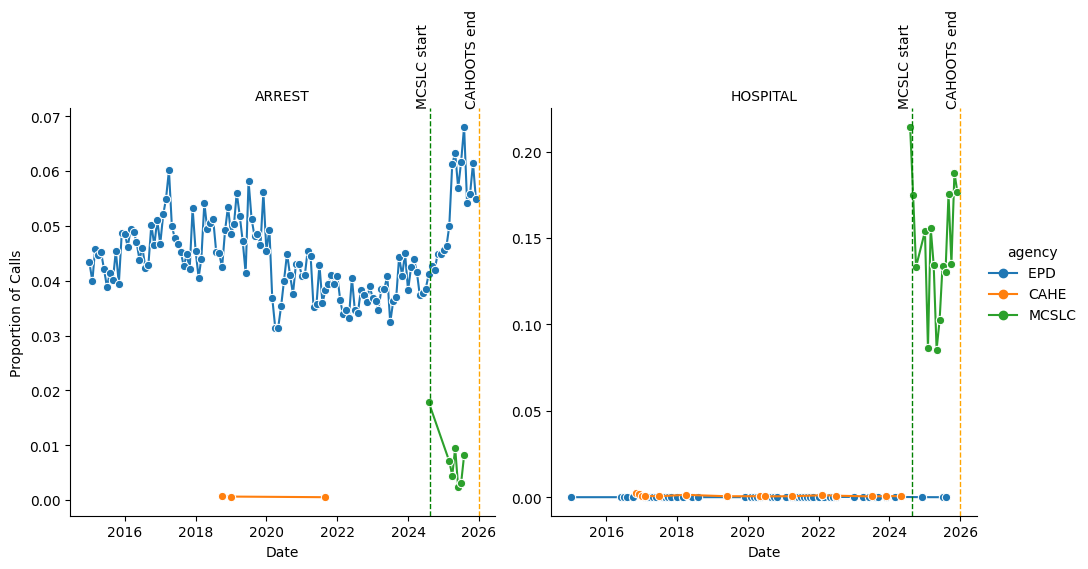

In [9]:
#visual respresentation of hospital and arrest by year and agency
mcslc_start = min(eugene[eugene["agency"] == "MCSLC"]["calltime"])
cahoots_end =  max(eugene[eugene["is_cahoots"] == True]["calltime"])
eugene["month_date"] = eugene["calltime"].dt.to_period("M").dt.to_timestamp()

print("Eugene")
#sub group of just hospital or arrest
sub = eugene[eugene["closed_as"].isin(["ARREST", "HOSPITAL"])]

#count by year and agency
counts = (sub.groupby(["month_date", "agency", "closed_as"]).size().reset_index(name="count")).fillna(0)
totals = eugene.groupby(["month_date", "agency"]).size().reset_index(name="total")
counts = counts.merge(totals, on=["month_date", "agency"])
counts["rate"] = counts["count"] / counts["total"]

#plot
g = sns.relplot(
    data=counts,
    x="month_date",
    y="rate",              
    hue="agency",
    col="closed_as",
    kind="line",
    marker="o",
    facet_kws={"sharey": False}
)

g.set_axis_labels("Date", "Proportion of Calls")
g.set_titles("{col_name}")

#plotting vertical lines for mcslc start and cahoots end
for ax in g.axes.flat:
    ax.axvline(mcslc_start, color="green", linestyle="--", linewidth=1)
    ax.axvline(cahoots_end, color="orange", linestyle="--", linewidth=1)

    ymax = ax.get_ylim()[1]

    ax.text(mcslc_start, ymax, "MCSLC start",
            rotation=90, va="bottom", ha="right")

    ax.text(cahoots_end, ymax, "CAHOOTS end",
            rotation=90, va="bottom", ha="right")


### *Springfield*

In [10]:
s_hosp = springfield[springfield["closed_as"] == "HOSPITAL"]
s_arr = springfield[springfield["closed_as"] == "ARREST"]
statements(s_hosp, "Springfield Hospital Transportations")
print("\n")
statements(s_arr, "springfield arrests")

In 3998 days 09:38:00 there were 0 / 344 Springfield Hospital Transportations completed by CAHOOTS this is 0.0%
The number of Springfield Hospital Transportations made by MCSLC was 72 which is 20.93%
The number of Springfield Hospital Transportations by EPD was 272 or 79.07%


In 4016 days 15:53:00 there were 3 / 30750 springfield arrests completed by CAHOOTS this is 0.01%
The number of springfield arrests made by MCSLC was 0 which is 0.0%
The number of springfield arrests by EPD was 30747 or 99.99%


Springfield


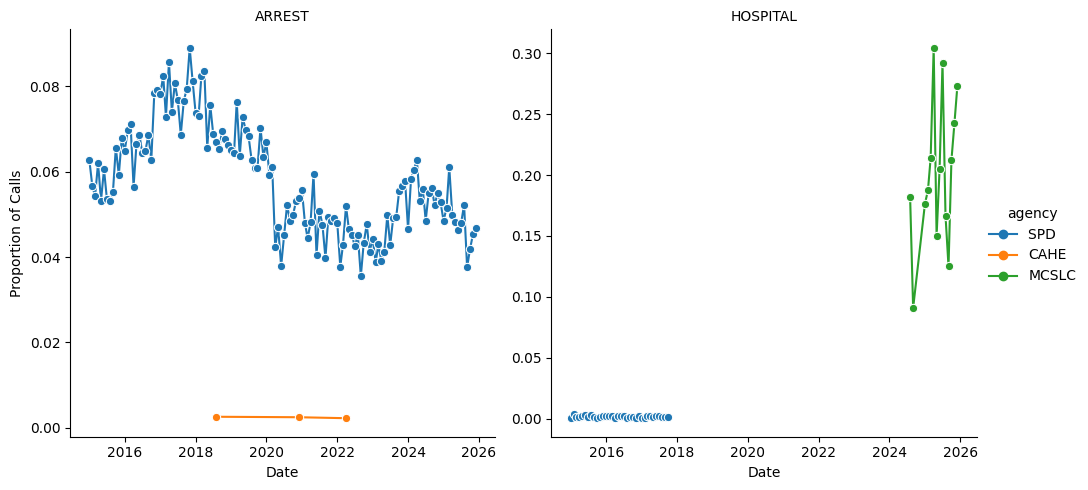

In [11]:
#visual respresentation of hospital and arrest by year and agency
springfield["month_date"] = springfield["calltime"].dt.to_period("M").dt.to_timestamp()

print("Springfield")
#sub group of just hospital or arrest
sub = springfield[springfield["closed_as"].isin(["ARREST", "HOSPITAL"])]

#count by year and agency
counts = (sub.groupby(["month_date", "agency", "closed_as"]).size().reset_index(name="count")).fillna(0)
totals = springfield.groupby(["month_date", "agency"]).size().reset_index(name="total")
counts = counts.merge(totals, on=["month_date", "agency"])
counts["rate"] = counts["count"] / counts["total"]

#plot
g = sns.relplot(
    data=counts,
    x="month_date",
    y="rate",              
    hue="agency",
    col="closed_as",
    kind="line",
    marker="o",
    facet_kws={"sharey": False}
)

g.set_axis_labels("Date", "Proportion of Calls")
g.set_titles("{col_name}")

**Overall change in hospital or arrest outcomes by city**

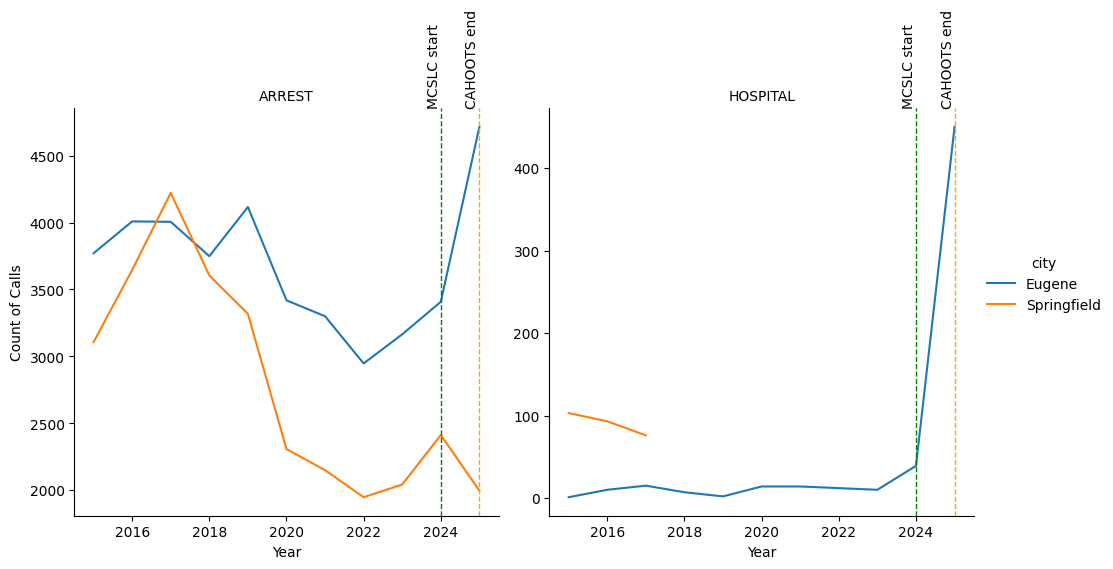

In [12]:
#create two dataframes one for eug and one for springfield
e = eugene[eugene["closed_as"].isin(["ARREST", "HOSPITAL"])]
s = springfield[springfield["closed_as"].isin(["ARREST", "HOSPITAL"])]

#calculate the counts by year
e_counts = (e.groupby(["yr", "closed_as"]).size().reset_index(name="count"))
s_counts = (s.groupby(["yr", "closed_as"]).size().reset_index(name="count"))

#add city label column
e_counts["city"] = "Eugene"
s_counts["city"] = "Springfield"
#combine the new dataframes
ttl_counts = pd.concat([e_counts, s_counts])

mcslc_start_year = mcslc_start.year
cahoots_end_year = cahoots_end.year

#plot
p = sns.relplot(data=ttl_counts, 
             x="yr", 
             y="count", 
             hue="city", 
             col="closed_as", 
             kind="line",
             facet_kws={"sharey": False})
p.set_axis_labels("Year", "Count of Calls")
p.set_titles("{col_name}")
#plotting vertical lines for mcslc start and cahoots end
for ax in p.axes.flat:
    ax.axvline(mcslc_start_year, color="green", linestyle="--", linewidth=1)
    ax.axvline(cahoots_end_year, color="orange", linestyle="--", linewidth=1)

    ymax = ax.get_ylim()[1]

    ax.text(mcslc_start_year, ymax, "MCSLC start",
            rotation=90, va="bottom", ha="right")

    ax.text(cahoots_end_year, ymax, "CAHOOTS end",
            rotation=90, va="bottom", ha="right")


## pt 2 Logistic Regression!

- goal: measure statistically if agency has an effect on hospital or arrest call outcomes especially between MCSLC and CAHOOTS.

In [13]:
springfield.rename(columns={"prime unit":"primeunit"}, inplace=True)

In [14]:
#Combine Eugene and Springfield dataframes
eug_sp = pd.concat([eugene, springfield], ignore_index=True).dropna()
#Filter for only arrests and hospital transports
eug_sp_ha = eug_sp[eug_sp["closed_as"].isin(["ARREST", "HOSPITAL"])].copy()
#create dependent variable (agency is independent)
eug_sp_ha["is_arrest"] = (eug_sp_ha["closed_as"] == "ARREST").astype(int) #arrest=1, hospital=0

#Train test split
#Use agency and city as predictors and include month and year to control for variations. 
X = pd.get_dummies(eug_sp_ha[["agency", "yr", "month", "city"]], drop_first=True)
y = eug_sp_ha["is_arrest"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#make predictions and evaluate accuracy and results
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion matrix:\n", confusion_matrix(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.9942128015618463
Confusion matrix:
 [[    0    83]
 [    0 14259]]
ROC-AUC: 0.7138264820274154


In [15]:
#Total counts by agency and closed_as hospital or arrest
c = (eug_sp.groupby(["city", "agency", "closed_as"])).size().reset_index(name="count")
c = c[c["closed_as"].isin(["HOSPITAL", "ARREST"])]
c.head(10)

,city,agency,closed_as,count
4,Eugene,CAHE,ARREST,3
23,Eugene,CAHE,HOSPITAL,22
58,Eugene,EPD,ARREST,40592
81,Eugene,EPD,HOSPITAL,70
124,Springfield,CAHE,ARREST,3
162,Springfield,SPD,ARREST,30747
184,Springfield,SPD,HOSPITAL,272


#  Pt 3 Fisher Exact Test

- what does this tell you and what comparing?

In [16]:
#[[CAHE hospital, CAHE arrest], [MCSLC hospital, MCSLC arrest]] eugene
mc_cah_table = [[22, 3], [482, 12]]
#[[eug cah arrest, eug cah hosp], [spr cah arrest, spr cah hosp]]
cahe_table = [[3, 22], [3, 0]]
#[[eug mc arrest, eug mc hosp], [spr mc arrest, spr mc hosp]]
mc_table = [[12, 482], [0, 72]]
#[[epd arr, epd hosp], [spd arr, spd hosp]]
pd_table = [[40592, 70], [30747, 272]]

def fisher(table):
    """Run a fisher exact test on a 2x2 table"""
    odds_ratio, p_value = fisher_exact(table)
    print(f"odds ratio = {odds_ratio} and p_value = {p_value}")

fisher(mc_cah_table)
fisher(cahe_table)
fisher(mc_table)
fisher(pd_table)


odds ratio = 0.1825726141078838 and p_value = 0.030637576496157545
odds ratio = 0.0 and p_value = 0.006105006105006104
odds ratio = inf and p_value = 0.37924933819721096
odds ratio = 5.129896064192093 and p_value = 6.212588039569836e-43


# Pt 4 Difference in Differences

In [22]:
#lets focus on ARREST closed_as labels from the graph above 
# right before logistic regression it seems the springfield and Eugene rates are similar
#Im going to filter the pre time to not include anything before 2018
ttl_length = len(eug_sp[eug_sp["calltime"] > "2018"])

arrest_only = eug_sp[eug_sp["closed_as"] == "ARREST"]
eug_sp_pre2018 = arrest_only[arrest_only["calltime"] > '2018']

#The time period of change is when MCSLC started in eugene (mcslc_start)
#Eugene is the treated group and springfield is the untreated group

treated_post = len(eug_sp_pre2018[(eug_sp_pre2018["city"] == "Eugene") & 
                              (eug_sp_pre2018["calltime"] > mcslc_start)]) / ttl_length
treated_pre = len(eug_sp_pre2018[(eug_sp_pre2018["city"] == "Eugene") & 
                              (eug_sp_pre2018["calltime"] < mcslc_start)]) / ttl_length

control_post = len(eug_sp_pre2018[(eug_sp_pre2018["city"] == "Springfield") & 
                              (eug_sp_pre2018["calltime"] > mcslc_start)]) / ttl_length
control_pre = len(eug_sp_pre2018[(eug_sp_pre2018["city"] == "Springfield") & 
                              (eug_sp_pre2018["calltime"] < mcslc_start)]) / ttl_length

did = (treated_post - treated_pre) - (control_post - control_pre)
print(did)


-0.002215003571640922


In [25]:
print(mcslc_start)
print(cahoots_end) #cahoots_end =  max(eugene[eugene["is_cahoots"] == True]["calltime"])

eugene[eugene["agency"] == "CAHE"]["calltime"].min()

temp = eugene[eugene["calltime"] > "2025-04-07 00:00:00"].copy()
temp = temp[temp["agency"] == "CAHE"]
temp.head()

2024-08-18 00:00:00
2025-12-31 12:28:18


,calltime,closed_as,agency,primeunit,is_cahoots,yr,month,month_date,city
1030564,2025-04-07 01:48:00,ASSISTED,CAHE,_4J79,True,2025,4,2025-04-01,Eugene
1030565,2025-04-07 01:56:26,DISREGARD,CAHE,_4J79,True,2025,4,2025-04-01,Eugene
1030568,2025-04-07 02:16:27,INFORMATION ONLY,CAHE,_CAHOT,True,2025,4,2025-04-01,Eugene
1030573,2025-04-07 02:54:53,ASSISTED,CAHE,_4J79,True,2025,4,2025-04-01,Eugene
1030576,2025-04-07 03:21:06,ASSISTED,CAHE,_4J79,True,2025,4,2025-04-01,Eugene
